In [2]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
from catboost import CatBoostClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Dropout, BatchNormalization,
    Flatten, Dense
)


TensorFlow version: 2.20.0
All imports successful!


In [4]:
from google.colab import files


uploaded = files.upload()


df = pd.read_csv('DSL-StrongPasswordData.csv')


Saving DSL-StrongPasswordData.csv to DSL-StrongPasswordData.csv


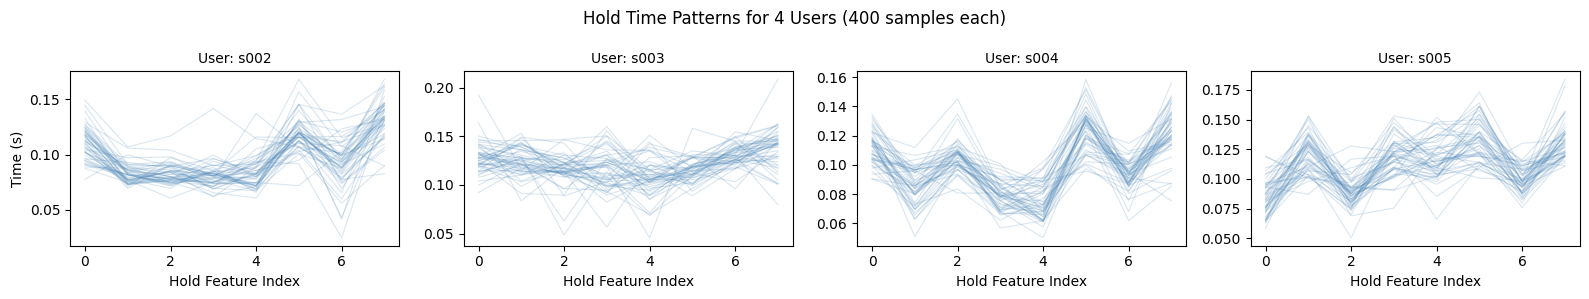

In [8]:
feature_cols = [c for c in df.columns ]

# Count feature types
hold_feats = [c for c in feature_cols if c.startswith('H.')]
dd_feats   = [c for c in feature_cols if c.startswith('DD.')]
ud_feats   = [c for c in feature_cols if c.startswith('UD.')]



users_sample = df['subject'].unique()[:4]
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
fig.suptitle('Hold Time Patterns for 4 Users (400 samples each)')

for i, user in enumerate(users_sample):
    user_data = df[df['subject'] == user][hold_feats[:8]].values
    for row in user_data[:50]:  # plot 50 samples
        axes[i].plot(row, alpha=0.2, color='steelblue', linewidth=0.8)
    axes[i].set_title(f'User: {user}', fontsize=10)
    axes[i].set_xlabel('Hold Feature Index')
    if i == 0: axes[i].set_ylabel('Time (s)')

plt.tight_layout()

plt.show()


In [9]:
def prepare_user_data(df, genuine_user, n_imposter_samples=8):

    feature_cols = [c for c in df.columns if c not in ['subject', 'sessionIndex', 'rep']]
    all_users    = df['subject'].unique().tolist()
    imposters    = [u for u in all_users if u != genuine_user]


    genuine_df = df[df['subject'] == genuine_user][feature_cols].copy()
    genuine_df['label'] = 1


    imposter_rows = []
    for imp in imposters:
        rows = df[df['subject'] == imp][feature_cols].sample(
            n=min(n_imposter_samples, len(df[df['subject'] == imp])),
            random_state=42
        )
        imposter_rows.append(rows)

    imposter_df = pd.concat(imposter_rows)
    imposter_df['label'] = 0

    combined = pd.concat([genuine_df, imposter_df]).reset_index(drop=True)
    X = combined[feature_cols].values
    y = combined['label'].values
    return X, y, feature_cols


# Pick the first user as our genuine user
genuine_user = df['subject'].unique()[0]
X, y, feature_cols = prepare_user_data(df, genuine_user)


print(f"Genuine user    : {genuine_user}")
print(f"Total samples   : {X.shape[0]}")
print(f"Features        : {X.shape[1]}")
print(f"Genuine (1)     : {sum(y == 1)}")
print(f"Imposter (0)    : {sum(y == 0)}")

Genuine user    : s002
Total samples   : 800
Features        : 31
Genuine (1)     : 400
Imposter (0)    : 400


In [10]:
def synthesize_data(X, y, n_copies=5):

    std = X.std(axis=0)
    synth_X = [X]
    synth_y = [y]

    for i in range(n_copies):

        noise = np.random.normal(0, std, X.shape)
        synth_X.append(X + noise)
        synth_y.append(y)

    X_aug = np.vstack(synth_X)
    y_aug = np.concatenate(synth_y)
    return X_aug, y_aug



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


X_train_aug, y_train_aug = synthesize_data(X_train, y_train, n_copies=5)


print(f"Before DS : {X_train.shape[0]} training rows")
print(f"After DS  : {X_train_aug.shape[0]} training rows")
print(f"Multiplier: {X_train_aug.shape[0] // X_train.shape[0]}x increase")
print(f"\nGenuine rows  : {sum(y_train_aug == 1)}")
print(f"Imposter rows : {sum(y_train_aug == 0)}")

Before DS : 560 training rows
After DS  : 3360 training rows
Multiplier: 6x increase

Genuine rows  : 1680
Imposter rows : 1680


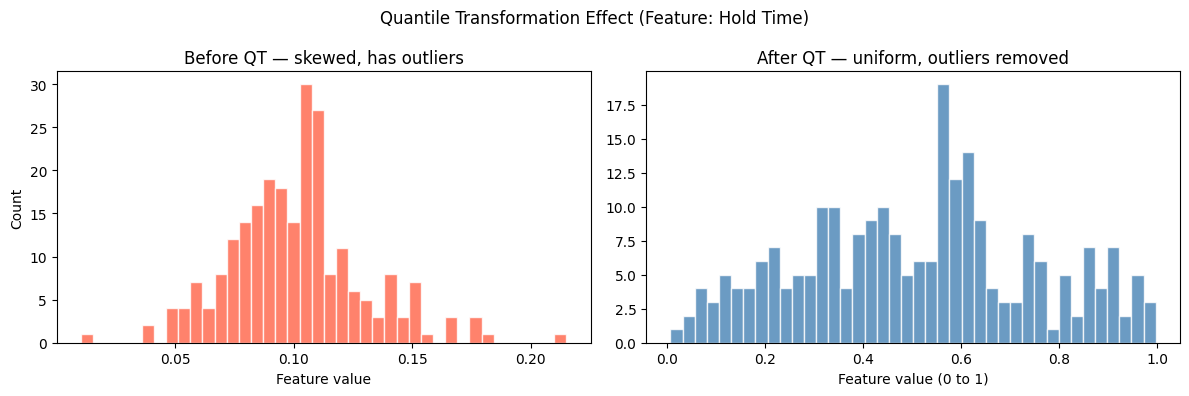

In [12]:
def apply_qt(X_train, X_test):

    qt = QuantileTransformer(output_distribution='uniform', random_state=42)
    X_train_qt = qt.fit_transform(X_train)  # fit on train only
    X_test_qt  = qt.transform(X_test)       # apply same transform to test
    return X_train_qt, X_test_qt


X_test_raw = X_test.copy()

X_train_qt, X_test_qt = apply_qt(X_train_aug, X_test)




fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Quantile Transformation Effect (Feature: Hold Time)')

axes[0].hist(X_test_raw[:, 0], bins=40, color='tomato', alpha=0.8, edgecolor='white')
axes[0].set_title('Before QT — skewed, has outliers')
axes[0].set_xlabel('Feature value')
axes[0].set_ylabel('Count')

axes[1].hist(X_test_qt[:, 0], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_title('After QT — uniform, outliers removed')
axes[1].set_xlabel('Feature value (0 to 1)')

plt.tight_layout()

plt.show()


In [13]:
def build_cnn(input_dim):

    inputs = Input(shape=(input_dim, 1), name='input')

    x = Conv1D(128, 7, padding='same', activation='elu', name='conv1')(inputs)
    x = Conv1D(128, 7, padding='same', activation='elu', name='conv2')(x)
    x = Dropout(0.4, name='drop1')(x)
    x = BatchNormalization(name='bn1')(x)

    x = Conv1D(64, 5, padding='same', activation='elu', name='conv3')(x)
    x = Conv1D(64, 5, padding='same', activation='elu', name='conv4')(x)
    x = Dropout(0.4, name='drop2')(x)
    x = BatchNormalization(name='bn2')(x)

    x = Flatten(name='flatten')(x)
    x = Dense(120, activation='elu', name='dense1')(x)
    x = Dropout(0.4, name='drop3')(x)
    x = Dense(60, activation='elu', name='dense2')(x)
    x = Dropout(0.4, name='drop4')(x)
    features = Dense(30, activation='elu', name='features')(x)  # 30-dim output

    output = Dense(1, activation='sigmoid', name='output')(features)
    full_model = Model(inputs, output, name='CNN_full')
    full_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    extractor = Model(inputs, features, name='CNN_extractor')

    return full_model, extractor


full_model, extractor = build_cnn(input_dim=X_train_qt.shape[1])

full_model.summary()

Model: "CNN_full"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 31, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 31, 128)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 31, 128)        │       114,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 31, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 31, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 31, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 31, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 31, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1984)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │       238,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,497 (1.62 MB)

 Trainable params: 425,113 (1.62 MB)

 Non-trainable params: 384 (1.50 KB)

Training CNN...
Input shape : (3360, 31, 1)
Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.8657 - loss: 0.3008 - val_accuracy: 0.8065 - val_loss: 0.4559
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.8697 - loss: 0.2954 - val_accuracy: 0.7649 - val_loss: 0.6476
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 133ms/step - accuracy: 0.8780 - loss: 0.2763 - val_accuracy: 0.7798 - val_loss: 0.4936
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.8886 - loss: 0.2620 - val_accuracy: 0.7738 - val_loss: 0.5838
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.8816 - loss: 0.2740 - val_accuracy: 0.7827 - val_loss: 0.5338
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.8909 - loss: 0.2558 - val_accuracy: 0.8036 - val_loss: 0.5557
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.8892 - loss: 0.2588 - val_accuracy: 0.7917 - val_loss: 0.5326
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accu

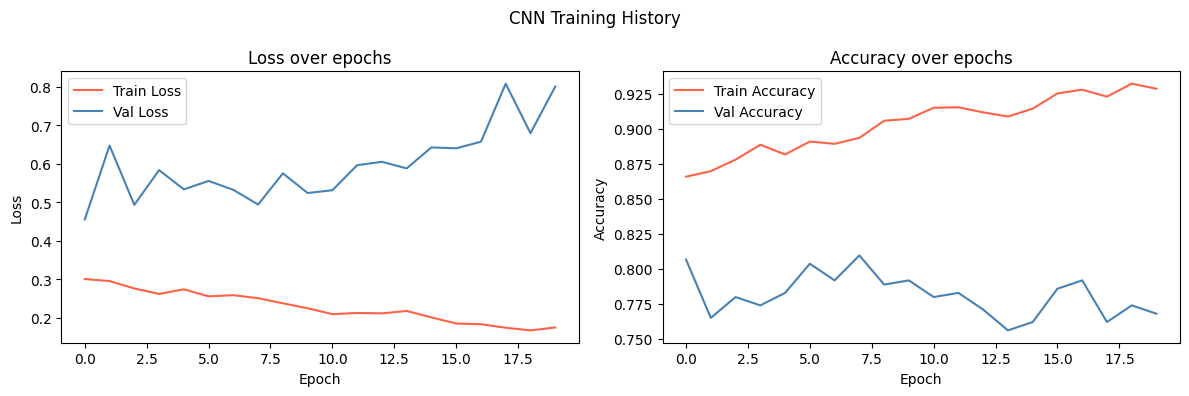

In [15]:

X_train_cnn = X_train_qt[..., np.newaxis]
X_test_cnn  = X_test_qt[..., np.newaxis]

print("Training CNN...")
print(f"Input shape : {X_train_cnn.shape}")

history = full_model.fit(
    X_train_cnn, y_train_aug,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Extract 30-dim feature vectors

train_features = extractor.predict(X_train_cnn, verbose=0)
test_features  = extractor.predict(X_test_cnn,  verbose=0)

print(f"Feature vector shape : {test_features.shape}")
print(f"Each sample is now a {test_features.shape[1]}-dimensional vector")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('CNN Training History')

axes[0].plot(history.history['loss'],     label='Train Loss',     color='tomato')
axes[0].plot(history.history['val_loss'], label='Val Loss',       color='steelblue')
axes[0].set_title('Loss over epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='tomato')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='steelblue')
axes[1].set_title('Accuracy over epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

plt.show()


In [ ]:

clf = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    verbose=0,
    random_seed=42
)
clf.fit(train_features, y_train_aug)

y_pred  = clf.predict(test_features)
y_proba = clf.predict_proba(test_features)[:, 1]

accuracy  = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred, zero_division=0) * 100
recall    = recall_score(y_test, y_pred, zero_division=0) * 100
f1        = f1_score(y_test, y_pred, zero_division=0) * 100
auc       = roc_auc_score(y_test, y_proba) * 100

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
eer_idx = np.argmin(np.abs(fpr - (1 - tpr)))
eer     = fpr[eer_idx] * 100

print(f"User: {genuine_user}")

print(f"Accuracy   : {accuracy:.2f}%")
print(f"Precision  : {precision:.2f}%")
print(f"Recall     : {recall:.2f}%")
print(f"F1 Score   : {f1:.2f}%")
print(f"AUC        : {auc:.2f}%")
print(f"EER        : {eer:.2f}%")


Training CatBoost classifier...

RESULTS — User: s002
Accuracy   : 92.08%
Precision  : 89.15%
Recall     : 95.83%
F1 Score   : 92.37%
AUC        : 97.87%
EER        : 10.00%

Note: paper reports AVERAGE across all 51 users = 99.95%


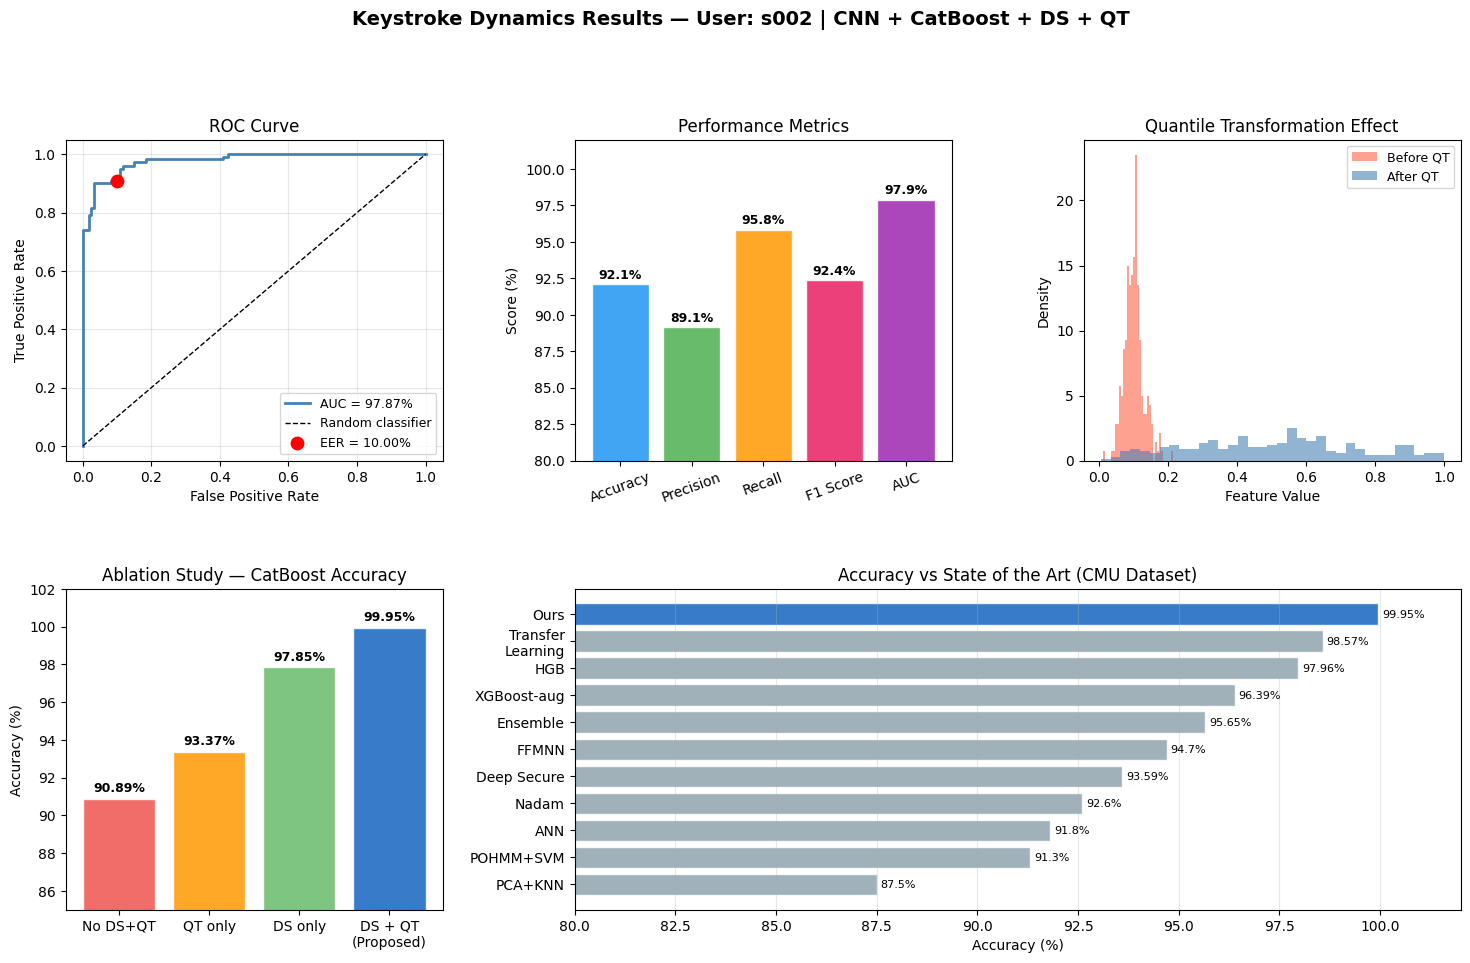

Full results chart saved as 04_full_results.png


In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f'Keystroke Dynamics Results — User: {genuine_user} | CNN + CatBoost + DS + QT',

)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.2f}%')
ax1.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
ax1.scatter(fpr[eer_idx], tpr[eer_idx], color='red', s=80, zorder=5, label=f'EER = {eer:.2f}%')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Plot 2: Metrics Bar Chart ──
ax2 = fig.add_subplot(gs[0, 1])
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']
metric_vals  = [accuracy, precision, recall, f1, auc]
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']
bars = ax2.bar(metric_names, metric_vals, color=colors, alpha=0.85, edgecolor='white')
ax2.set_ylim(80, 102)
ax2.set_title('Performance Metrics')
ax2.set_ylabel('Score (%)')
ax2.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, metric_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Plot 3: Feature Distribution Before/After QT ──
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(X_test_raw[:, 0], bins=35, alpha=0.6, color='tomato',    label='Before QT', density=True)
ax3.hist(X_test_qt[:, 0],  bins=35, alpha=0.6, color='steelblue', label='After QT',  density=True)
ax3.set_title('Quantile Transformation Effect')
ax3.set_xlabel('Feature Value')
ax3.set_ylabel('Density')
ax3.legend(fontsize=9)

# ── Plot 4: Ablation Study (paper Table 3) ──
ax4 = fig.add_subplot(gs[1, 0])
ablation_methods = ['No DS+QT', 'QT only', 'DS only', 'DS + QT\n(Proposed)']
ablation_acc     = [90.89, 93.37, 97.85, 99.95]
ablation_colors  = ['#ef5350','#FF9800','#66BB6A','#1565C0']
bars2 = ax4.bar(ablation_methods, ablation_acc, color=ablation_colors, alpha=0.85, edgecolor='white')
ax4.set_ylim(85, 102)
ax4.set_title('Ablation Study — CatBoost Accuracy')
ax4.set_ylabel('Accuracy (%)')
for bar, val in zip(bars2, ablation_acc):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Plot 5: Comparison vs Prior Work ──
ax5 = fig.add_subplot(gs[1, 1:])
prior_methods = ['PCA+KNN','POHMM+SVM','ANN','Nadam','Deep Secure',
                 'FFMNN','Ensemble','XGBoost-aug','HGB','Transfer\nLearning','Ours']
prior_acc     = [87.5, 91.3, 91.8, 92.6, 93.59, 94.7, 95.65, 96.39, 97.96, 98.57, 99.95]
bar_colors    = ['#90A4AE'] * 10 + ['#1565C0']
bars3 = ax5.barh(prior_methods, prior_acc, color=bar_colors, alpha=0.85, edgecolor='white')
ax5.set_xlim(80, 102)
ax5.set_title('Accuracy vs State of the Art (CMU Dataset)')
ax5.set_xlabel('Accuracy (%)')
for bar, val in zip(bars3, prior_acc):
    ax5.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=8)
ax5.grid(axis='x', alpha=0.3)

plt.savefig('04_full_results.png', dpi=130, bbox_inches='tight')
plt.show()
print("Full results chart saved as 04_full_results.png")